# What is gradient descent -- actually -- doing? Watching it walk on the loss surface

Previous notebooks treated the optimizer as a black box: `loss.backward()`, `optimizer.step()`, loss went down. This notebook opens the box for the simplest possible case — a model with exactly **2 parameters** — so the loss surface is a surface we can draw, and the optimizer's steps become a path we can look at.

**The model:** `y = wx + b` — two numbers, `w` (weight) and `b` (bias), fitting 1-D data. (This is literally the model from `pytorch_basics.ipynb`.)

**The trick:** with only 2 parameters, the loss `MSE(w, b)` is a function of exactly 2 variables — so we can compute it on a grid of `(w, b)` pairs and *draw* it: a 3-D bowl, or a top-down contour map. Training = rolling a ball downhill on that map.

We run gradient descent **by hand** — no `nn.Module`, no optimizer class, just torch autograd on `w` and `b` with `requires_grad=True` and the update `w -= lr * w.grad` — first one careful walk, then the same walk at 4 learning rates to see slow crawl / steady descent / overshoot+recovery / divergence on one contour map.

Companion to `pytorch_basics.ipynb`: same data-generating style, same `device` convention; the only new thing is drawing the loss surface instead of just reporting the loss number.

## Setup

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

## 1. The data: a small noisy line

Same recipe as `pytorch_basics.ipynb`: known weight and bias, a little noise, 50 points — only the x-range is doubled (`[0, 2)` in steps of `0.04`), which makes the bowl's sides steeper, so the four learning-rate walks below separate cleanly. The surface's minimum sits near `(w, b) = (0.7, 0.3)` — we will literally see it as the bottom of the bowl.

In [4]:
torch.manual_seed(42)

weight, bias = 0.7, 0.3
X = torch.arange(0, 2, 0.04).unsqueeze(dim=1)          # x-span [0, 2), 50 points: widens the bowl's curvature
noise = 0.05 * torch.randn_like(X)
y = weight * X + bias + noise

X.shape, y.shape

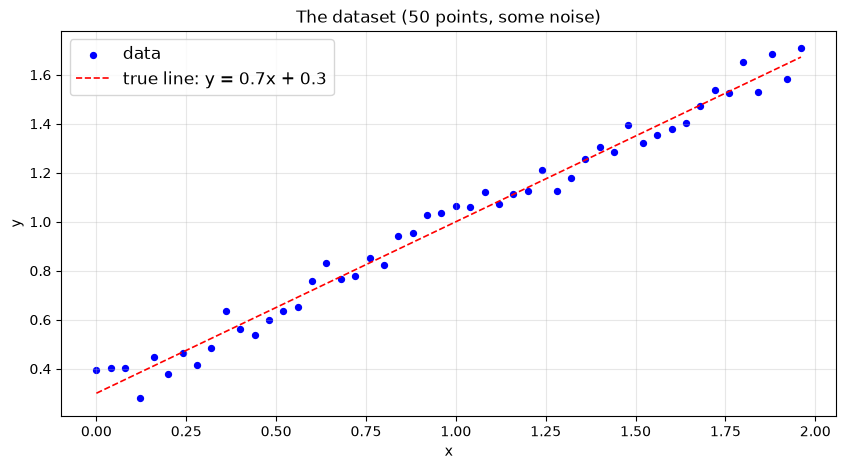

In [5]:
plt.figure(figsize=(10, 5))
plt.scatter(X.cpu(), y.cpu(), s=18, c="b", label="data")
plt.plot(X, weight * X + bias, c="r", ls="--", lw=1.2, label=f"true line: y = {weight}x + {bias}")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(prop={"size": 12})
plt.title("The dataset (50 points, some noise)")
plt.grid(alpha=0.3)
plt.show()

## 2. The loss surface: MSE as a function of (w, b)

The loss for this *fixed* dataset is a function of only the two parameters:

$$\text{loss}(w, b) = \frac{1}{n}\sum_i (w x_i + b - y_i)^2$$

We evaluate it on a 60×60 meshgrid of $(w, b)$ pairs — 3600 full MSE calculations in one vectorised `numpy` pass (the same formula as training, just evaluated everywhere at once). The grid ranges below are chosen wide enough to contain a start point up at $(w, b) = (-1, 3)$'s descent route and tight enough that the bowl fills the frame.

In [7]:
# meshgrid over (w, b)
w_vals = np.linspace(-1.2, 1.6, 60)
b_vals = np.linspace(-0.5, 3.3, 60)
W, B = np.meshgrid(w_vals, b_vals)

# MSE on the whole grid at once: [60,60,1] vs [50] -> [60,60,50] -> mean over x
Xn, yn = X.cpu().numpy().ravel(), y.cpu().numpy().ravel()
loss_grid = ((W[..., None] * Xn + B[..., None] - yn) ** 2).mean(axis=-1)

loss_grid.shape, loss_grid.min()

Two views of the same surface: **3-D bowl** (left) and **top-down contour map** (right). The white cross is the lowest grid point; the red star is the expected minimum at the true `(w, b) = (0.7, 0.3)`.

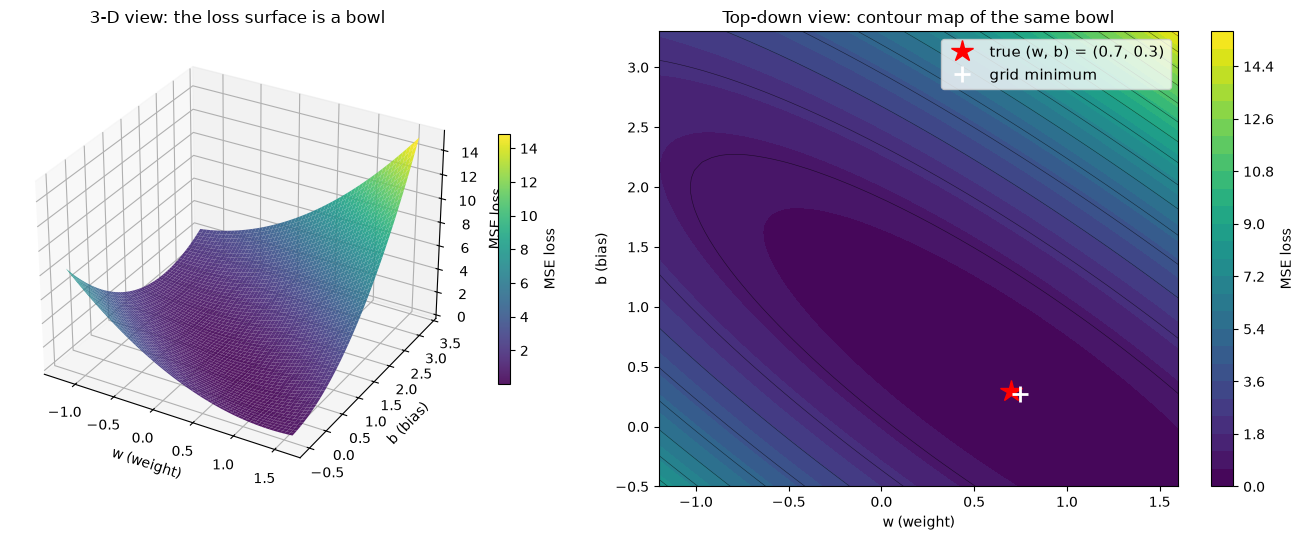

In [9]:
fig = plt.figure(figsize=(14, 5.5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf = ax1.plot_surface(W, B, loss_grid, cmap="viridis", rstride=1, cstride=1, alpha=0.9)
ax1.set_xlabel("w (weight)"); ax1.set_ylabel("b (bias)"); ax1.set_zlabel("MSE loss")
ax1.set_title("3-D view: the loss surface is a bowl")
ax1.view_init(elev=30, azim=-60)
fig.colorbar(surf, ax=ax1, shrink=0.55, label="MSE loss")

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(W, B, loss_grid, levels=25, cmap="viridis")
ax2.contour(W, B, loss_grid, levels=15, colors="black", linewidths=0.4, alpha=0.6)
ax2.plot(weight, bias, "r*", markersize=16, label="true (w, b) = (0.7, 0.3)")
i0, j0 = np.unravel_index(np.argmin(loss_grid), loss_grid.shape)
ax2.plot(W[i0, j0], B[i0, j0], "w+", markersize=12, markeredgewidth=2, label="grid minimum")
ax2.set_xlabel("w (weight)"); ax2.set_ylabel("b (bias)")
ax2.set_title("Top-down view: contour map of the same bowl")
ax2.legend(prop={"size": 11})
fig.colorbar(cs, ax=ax2, label="MSE loss")

fig.tight_layout()
plt.show()

That bowl **is** the training problem. A model with 2 parameters has a 2-axis landscape; every step of training moves one ball one step further down it. (Deep nets: same picture, hundreds of axes — impossible to draw, same mechanics.)

## 3. Gradient descent, by hand, exactly on this surface

No `nn.Module`, no optimizer class. Just two tensors that remember they need gradients and the update rule every optimizer hides inside:

$$w \leftarrow w - \text{lr} \cdot \frac{\partial\,\text{loss}}{\partial w}, \qquad b \leftarrow b - \text{lr} \cdot \frac{\partial\,\text{loss}}{\partial b}$$

The loss at point $(w, b)$ is `(w * X + b - y)**2).mean()` — the same expression as the grid. Autograd gives us both partial derivatives at the current point; we step *against* them (downhill) and repeat. The walker starts far from home: $(w, b) = (-1.0, 3.0)$.

In [11]:
def run_gd(lr=0.1, steps=50, w0=-1.0, b0=3.0):
    """Hand-rolled gradient descent on loss = mean((w*x + b - y)^2).

    Returns a list of (w, b, loss) tuples — one per step — so the walk can be
    drawn on the (w, b) contour map afterwards.
    """
    w = torch.tensor(float(w0), requires_grad=True)
    b = torch.tensor(float(b0), requires_grad=True)
    path = []
    for step in range(steps):
        loss = ((w * X + b - y) ** 2).mean()   # the exact same formula as loss_grid
        loss.backward()                        # autograd computes w.grad, b.grad
        path.append((w.item(), b.item(), loss.item()))
        with torch.no_grad():                  # hand-written update — autograd must not watch
            w -= lr * w.grad
            b -= lr * b.grad
        w.grad = None
        b.grad = None
    return path

def trim_path(path, wlim, blim):
    # Keep the in-frame part of a walk + one clamped exit point.
    # A diverged walk reaches |w|, |b| ~ 1e9 within 50 steps; drawing it raw
    # stretches the axes to 1e9 and turns the whole figure into one red line.
    # Trimming keeps the drawn frame honest while still showing the exit.
    inside = [(p[0], p[1]) for p in path
              if wlim[0] <= p[0] <= wlim[1] and blim[0] <= p[1] <= blim[1]]
    if len(inside) == len(path):
        return inside
    wL, bL = path[len(inside)][0], path[len(inside)][1]     # first escaped point
    wC = min(max(wL, wlim[0] - 0.08), wlim[1] + 0.08)
    bC = min(max(bL, blim[0] - 0.08), blim[1] + 0.08)
    return inside + [(wC, bC)]

path = run_gd(lr=0.2)
print(f"start loss {path[0][2]:.3f} at (w, b) = ({path[0][0]:.3f}, {path[0][1]:.3f})")
print(f"end   loss {path[-1][2]:.3f} at (w, b) = ({path[-1][0]:.3f}, {path[-1][1]:.3f})   [true: (0.7, 0.3)]")

start loss 2.024 at (w, b) = (-1.000, 3.000)
end   loss 0.006 at (w, b) = (0.611, 0.408)   [true: (0.7, 0.3)]


The walk ends within a hair of the true `(0.7, 0.3)` — the star — after 50 steps. Drawn on the contour map:

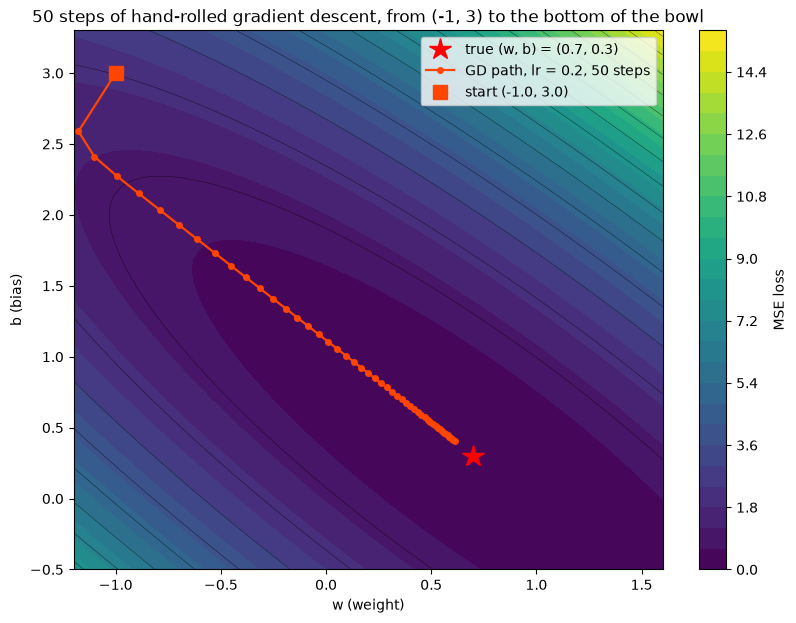

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 7))
cs = ax.contourf(W, B, loss_grid, levels=25, cmap="viridis")
ax.contour(W, B, loss_grid, levels=15, colors="black", linewidths=0.4, alpha=0.6)
ax.plot(weight, bias, "r*", markersize=16, label="true (w, b) = (0.7, 0.3)")

ws = [p[0] for p in path]; bs = [p[1] for p in path]
ax.plot(ws, bs, "o-", color="orangered", markersize=4, lw=1.6, label="GD path, lr = 0.2, 50 steps")
ax.plot(ws[0], bs[0], "s", color="orangered", markersize=10, label="start (-1.0, 3.0)")

ax.set_xlabel("w (weight)"); ax.set_ylabel("b (bias)")
ax.set_title("50 steps of hand-rolled gradient descent, from (-1, 3) to the bottom of the bowl")
ax.legend(prop={"size": 10})
fig.colorbar(cs, ax=ax, label="MSE loss")
plt.show()

The path starts wide (up at $b \approx 3$, off the left edge of the surface) and dives to the star — each arrow of it is the minus-gradient direction.

## 4. One knob, four walks: lr = 0.02, 0.1, 0.3, 0.6 on the same contour map

Same start $(-1.0, 3.0)$, same 50 steps, same surface — only the step size changes. Predictions (validated below by the paths and the loss curves):

- `lr = 0.02`: still nowhere near the bowl after 50 steps — a **slow crawl**
- `lr = 0.1`: clean, steady slide to the bottom — the **just right** walk
- `lr = 0.3`: overshoots the valley, zigzags across it, eventually settles — **overshoot + recovery**
- `lr = 0.6`: every step lands *further out of the bowl* than the last — **divergence**, and fast

In [15]:
LRS_VIZ = [0.02, 0.1, 0.3, 0.6]
paths = {lr: run_gd(lr=lr) for lr in LRS_VIZ}

for lr, p in paths.items():
    print(f"lr={lr:<5g} end loss {p[-1][2]:<12.4g} at (w, b) = ({p[-1][0]:.3f}, {p[-1][1]:.3f}), min loss so far {min(q[2] for q in p):.4g}")

lr=0.02  end loss 0.8407       at (w, b) = (-0.810, 2.066), min loss so far 0.8407
lr=0.1   end loss 0.07212      at (w, b) = (0.263, 0.812), min loss so far 0.07212
lr=0.3   end loss 0.002797     at (w, b) = (0.682, 0.325), min loss so far 0.002797
lr=0.6   end loss 5.574e+18    at (w, b) = (-1223456256.000, -1053837760.000), min loss so far 2.024


All four walks overlaid on one contour map — same start, four very different descents:

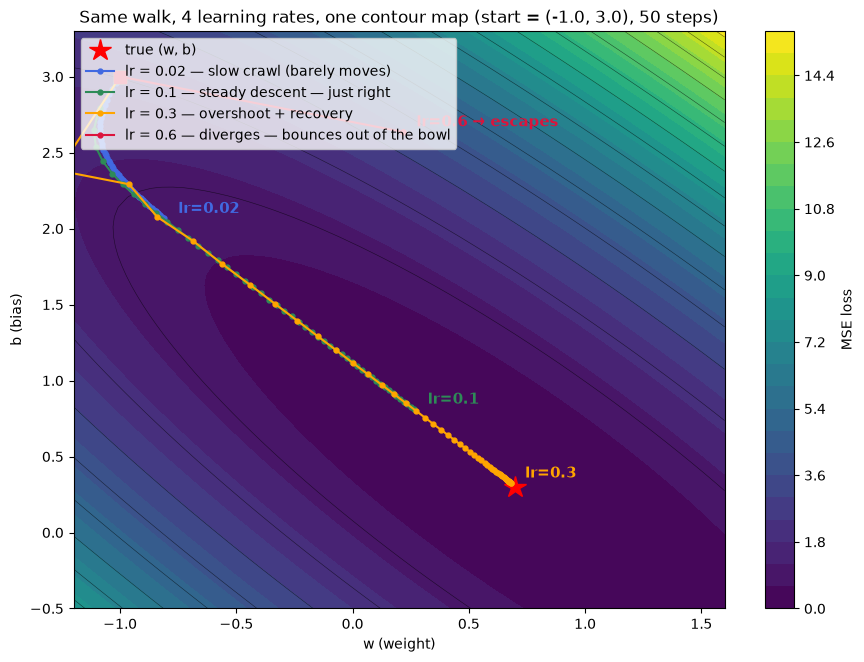

In [17]:
fig, ax = plt.subplots(figsize=(10.5, 7.5))
cs = ax.contourf(W, B, loss_grid, levels=25, cmap="viridis")
ax.contour(W, B, loss_grid, levels=15, colors="black", linewidths=0.4, alpha=0.6)
ax.plot(weight, bias, "r*", markersize=16, label="true (w, b)")

colors = ["royalblue", "seagreen", "orange", "crimson"]
labels = {
    0.02: "slow crawl (barely moves)",
    0.1:  "steady descent — just right",
    0.3:  "overshoot + recovery",
    0.6:  "diverges — bounces out of the bowl",
}
W_LIM, B_LIM = (-1.2, 1.6), (-0.5, 3.3)
for lr, color in zip(LRS_VIZ, colors):
    if lr == 0.6:
        ws, bs = zip(*trim_path(paths[lr], W_LIM, B_LIM))   # diverged: trim to the frame
    else:
        ws = [p[0] for p in paths[lr]]; bs = [p[1] for p in paths[lr]]
    ax.plot(ws, bs, "o-", color=color, markersize=3.5, lw=1.5, label=f"lr = {lr:g} — {labels[lr]}")
    ax.plot(ws[0], bs[0], "s", color=color, markersize=9)
    ax.annotate(f"lr={lr:g}" + (" \u2192 escapes" if lr == 0.6 else ""), (ws[-1], bs[-1]),
                textcoords="offset points", xytext=(10, 4), color=color,
                fontsize=11, fontweight="bold")

ax.set_xlim(*W_LIM); ax.set_ylim(*B_LIM)
ax.set_xlabel("w (weight)"); ax.set_ylabel("b (bias)")
ax.set_title("Same walk, 4 learning rates, one contour map (start = (-1.0, 3.0), 50 steps)")
ax.legend(prop={"size": 10}, loc="upper left")
fig.colorbar(cs, ax=ax, label="MSE loss")
plt.show()

## 5. The loss curves behind the four walks

The same story, plotted as loss vs step (log y-axis) — the shape of each walk in 1-D:

- `lr = 0.02` (blue): a nearly flat crawl — loss barely moves in 50 steps
- `lr = 0.1` (green): a smooth glide down
- `lr = 0.3` (orange): overshoots the valley, zigzags across it, and still converges — costly but harmless
- `lr = 0.6` (red): climbs — each bounce lands *further out* than the last, the classic divergence signature

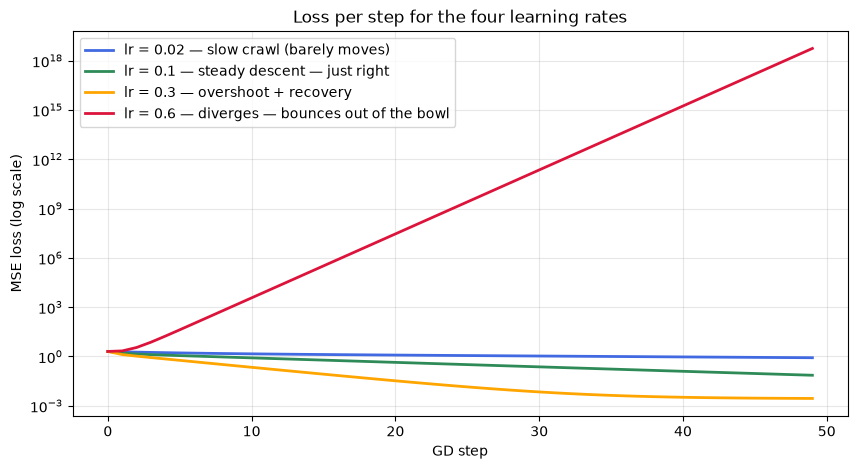

In [19]:
plt.figure(figsize=(10, 5))
for lr, color in zip(LRS_VIZ, colors):
    losses = [p[2] for p in paths[lr]]
    plt.plot(losses, color=color, lw=2, label=f"lr = {lr:g} — {labels[lr]}")
plt.yscale("log")
plt.xlabel("GD step"); plt.ylabel("MSE loss (log scale)")
plt.title("Loss per step for the four learning rates")
plt.legend(prop={"size": 10})
plt.grid(True, which="both", alpha=0.3)
plt.show()

## 6. Zoom: the last stretch near the valley floor

The dramatic differences between walks are easiest to read up close. Blue never even reaches the valley in 50 steps; green just barely lands; orange dynamically overshoots across the dish before settling; red is ejected into the wild blue yonder.

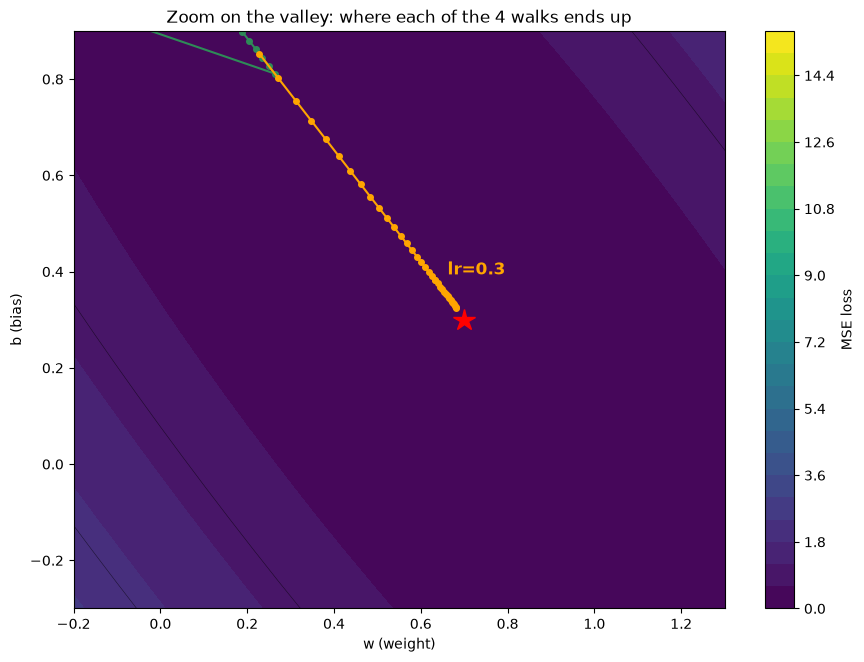

In [21]:
fig, ax = plt.subplots(figsize=(10.5, 7.5))
cs = ax.contourf(W, B, loss_grid, levels=25, cmap="viridis")
ax.contour(W, B, loss_grid, levels=15, colors="black", linewidths=0.4, alpha=0.6)
ax.plot(weight, bias, "r*", markersize=16)

Z_LIM = ((-0.2, 1.3), (-0.3, 0.9))   # zoom onto the valley floor
for lr, color in zip(LRS_VIZ, colors):
    ws, bs = zip(*trim_path(paths[lr], *Z_LIM))         # clip every walk to the zoom window
    ax.plot(ws, bs, "o-", color=color, markersize=4, lw=1.5)
    ax.annotate(f"lr={lr:g}" + (" \u2192 escaped" if lr == 0.6 else ""), (ws[-1], bs[-1]),
                textcoords="offset points", xytext=(9, 4), color=color,
                fontsize=12, fontweight="bold")

ax.set_xlim(-0.2, 1.3); ax.set_ylim(-0.3, 0.9)
ax.set_xlabel("w (weight)"); ax.set_ylabel("b (bias)")
ax.set_title("Zoom on the valley: where each of the 4 walks ends up")
fig.colorbar(cs, ax=ax, label="MSE loss")
plt.show()

## 7. What we learned

1. **Training is walking downhill on a loss surface.** With 2 parameters, `MSE(w, b)` is literally a drawable bowl, and every training step is a move on that map. Deep nets: same mechanics, hundreds of axes, nothing conceptually new — just impossible to draw.
2. **`loss.backward()` is the calculus, and autograd does it.** The whole of "gradient descent" beyond that is one line: `w -= lr * w.grad`. There is no hidden magic inside `optimizer.step()` (for vanilla GD).
3. **The learning rate is the step length on that map.** Too small → the walk never arrives (here: `0.02`). Just right → a steady glide to the bottom (here: `0.1`). A bit large → overshoot, rumble, sometimes still land fine (here: `0.3`). Too large → each step lands *further out* than the last and the walk diverges: the surface literally throws the ball out of the bowl (here: `0.6`).
4. **The divergence boundary is not far above the sweet spot.** Here `0.1` glides, `0.3` works but expensively, `0.6` is dead. That is why "loss going up mid-training" is a signal to cut the lr, not to train longer.
5. **Overshoot is not automatically failure.** The `lr=0.3` walk crossed the valley repeatedly, wobbled — and still ended near the right `(w, b)`. Momentum methods (SGD+momentum, Adam) deliberately embrace controlled overshoot to move faster.

Next idea: **learning-rate schedules** — one step size is not sacred. Take huge steps while far from the bottom, then shrink the lr as the valley flattens (that is what cosine decay / step decay do, and why they beat a constant lr so often).